# 초기 100사이클 기반 배터리 총수명 예측

**DS Mini Project · 울산 캠퍼스 3반 · U090 이나현**

DAY1 설계에 따라 총수명 회귀를 구현한다. 원본에서 입력을 다시 생성하고 정책별 교차검증으로 모델·피처·타깃 변환·하이퍼파라미터를 비교한다. 그래프마다 확인한 내용과 모델 설계 또는 결과 해석을 연결한다.

원본 3개 `.mat` 파일은 README의 경로에 준비하고 `requirements.txt`를 설치한 Python 환경을 선택한다. 전체 실행은 1,470회 CV 학습과 최종 평가를 수행한다.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
while not (ROOT / 'day2/config/design.json').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('프로젝트 폴더에서 노트북을 실행하세요.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
OUTPUT = ROOT / 'day2/results'
from day2.experiment import prepare, tune, evaluate, load_design
from day2.plots import make_figures
design, holdout = load_design(ROOT)
print('Python:', sys.version.split()[0])
print('문제:', design['task'], '| 목표:', design['target'])

Python: 3.11.15
문제: regression | 목표: cycle_life


## 1. EDA에서 확인한 데이터 특성

Batch1·2·3 모두 관측 EDA의 대상이다. 수명이 없는 10셀은 EDA에 남기고 학습·평가에서 제외한다. Batch1의 빈 첫 기록은 결측으로 표시하되 원래 사이클 번호는 유지한다. 스파이크와 장수명 이상치 후보는 제거하지 않는다.

### Q1. 수명 분포 → 회귀와 Batch별 평가

수명 중앙값은 Batch1 858.5, Batch2 472, Batch3 1005.5사이클이다. <500셀은 각각 0·28·0개로 큰 차이가 있다. Batch1의 550사이클 분류는 1:45로 불균형해 회귀를 선택했다. Batch2의 짧은 수명과 Batch3의 장수명에 대한 오류를 별도로 확인한다.

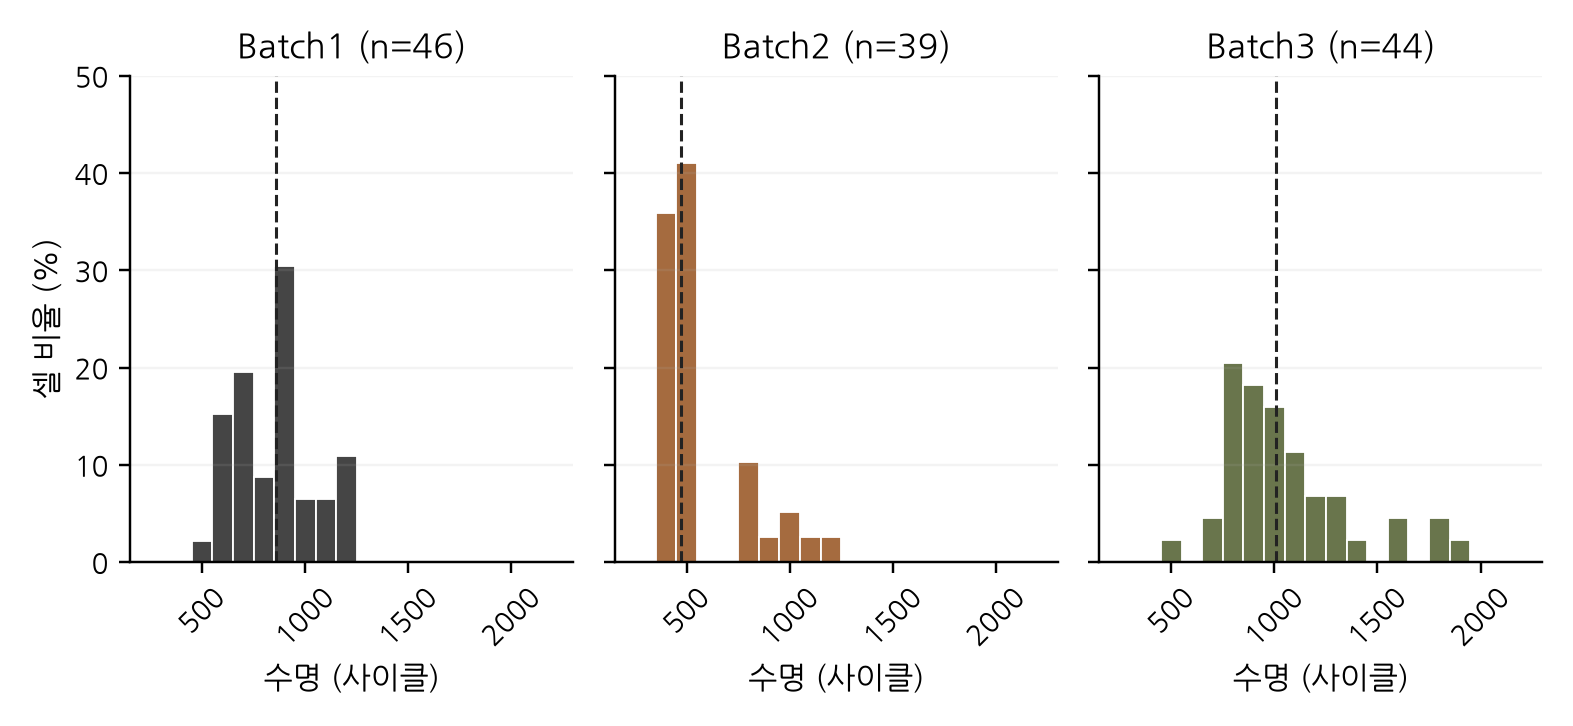

In [2]:
display(Image(filename=str(ROOT / 'day1/readable_figures/01_life_histograms.png'), width=1000))

### Q2. 열화 곡선 → 강건한 요약과 미래 정보 제외

초기 Qd에는 용량 상승과 스파이크가 있고 전체 곡선에서는 이후 열화가 가속될 수 있다. 평균·표준편차만으로 요약하지 않고 중앙값·IQR을 비교한다. 아래 그림은 Batch별 중앙값과 사분위 범위다. 전체 수명 곡선으로 찾은 knee는 설명용 EDA이며 미래 정보라 모델 입력에 넣지 않는다.

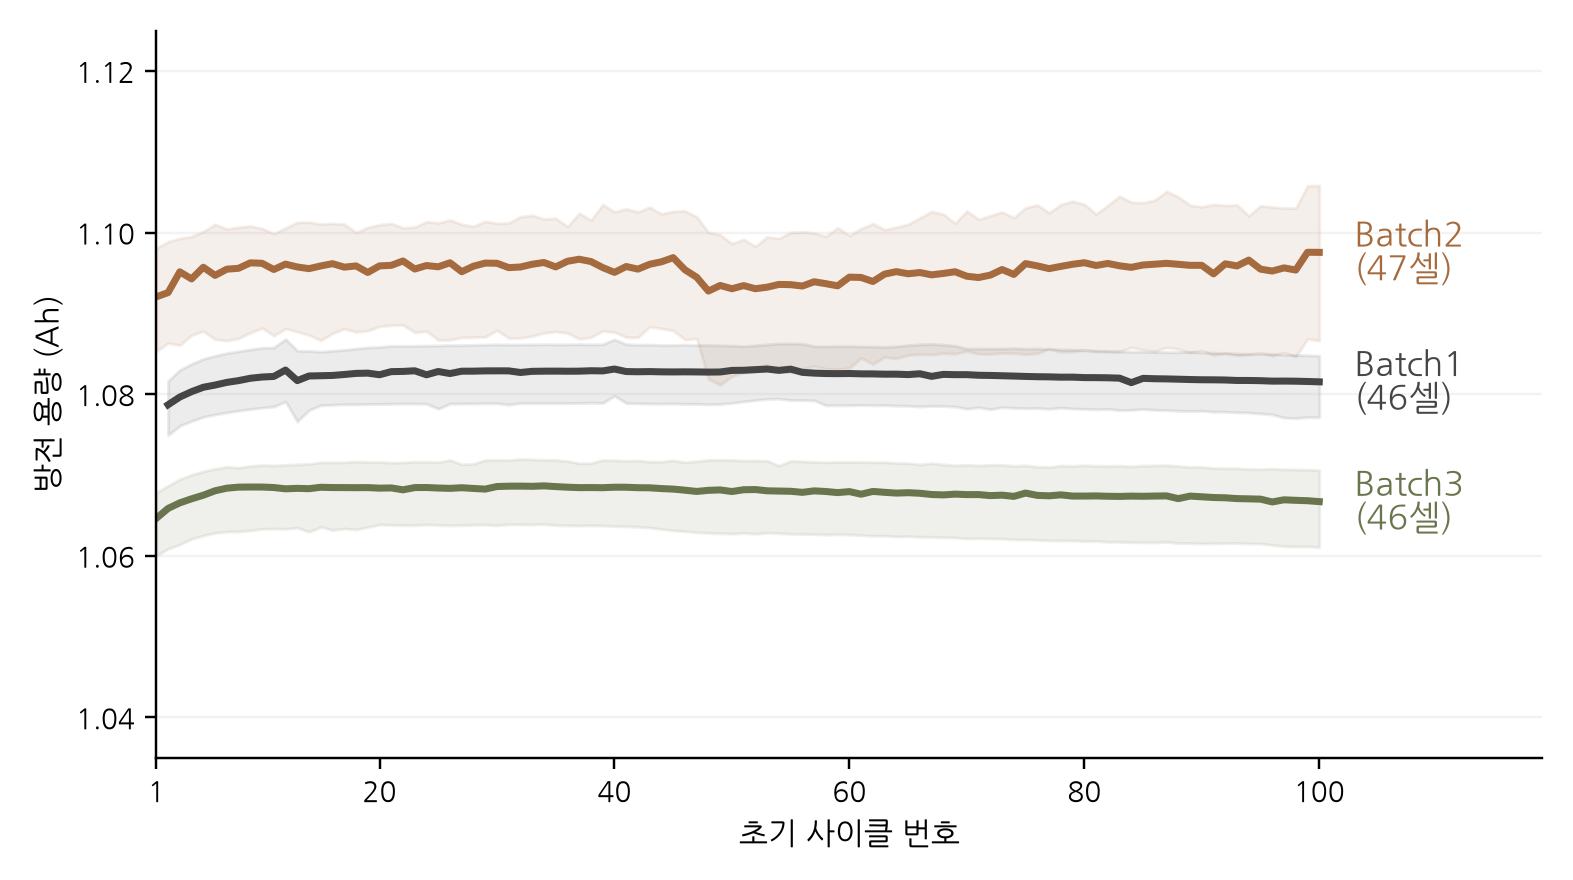

In [3]:
display(Image(filename=str(ROOT / 'day1/readable_figures/06_capacity_early100_zoom.png'), width=1000))

### Q3. ΔQ(V) → log분산 기본 피처와 한 변수 기준

ΔQ는 원래 cycle100의 Q(V)에서 cycle10의 Q(V)를 뺀 값이다. Batch1의 log분산과 수명 Pearson r=-0.886으로 강한 음의 관계를 보였다. 이 신호의 단독 설명력을 한 변수 모델로 확인하고, 최솟값 대체군 B도 비교한다.

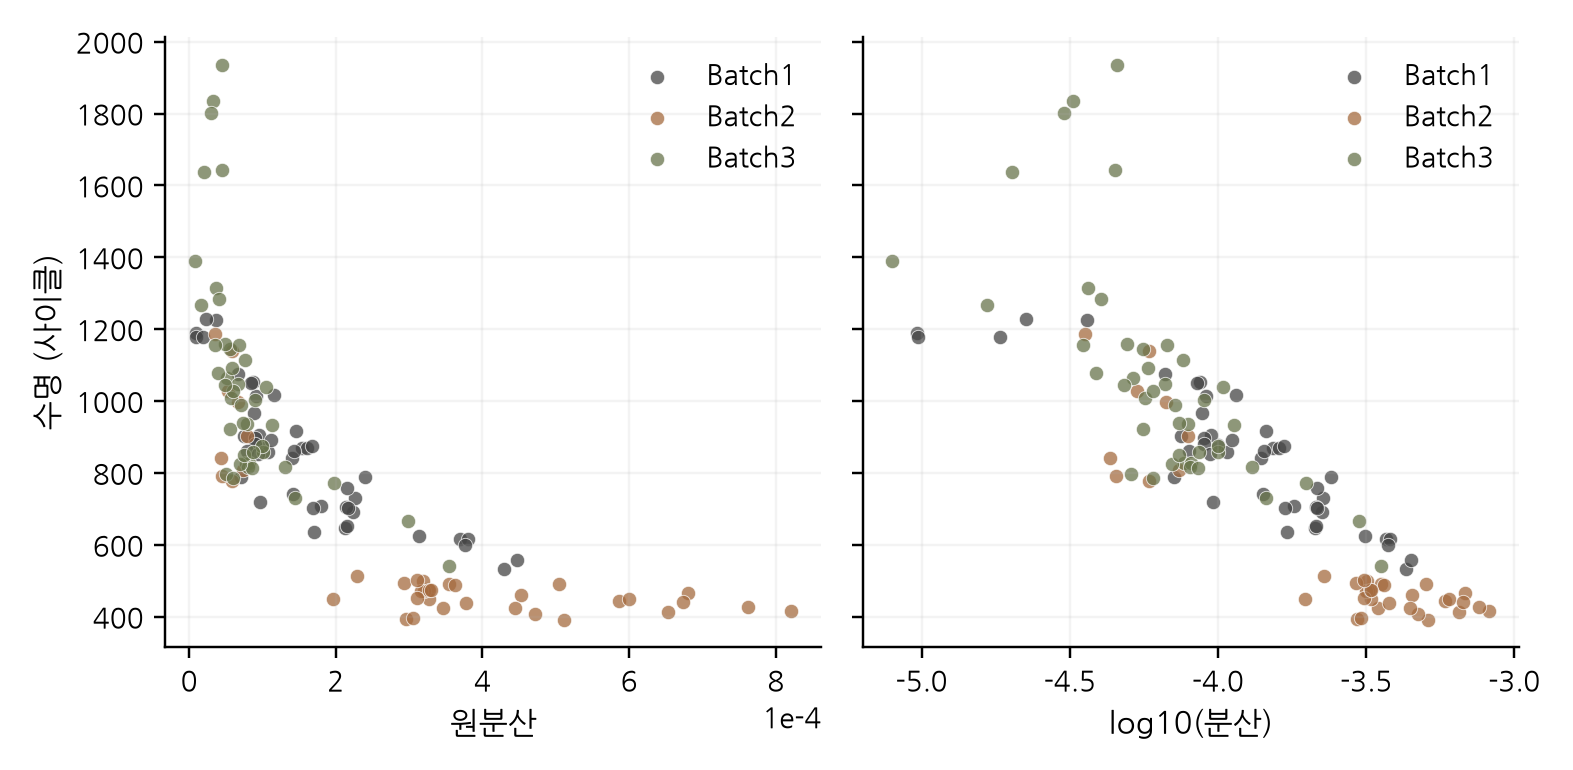

In [4]:
display(Image(filename=str(ROOT / 'day1/readable_figures/11_deltaq_variance_scatter.png'), width=1000))

### Q4. 충전 조건 → 별도 피처군과 정책별 분리

충전시간과 수명의 Pearson r은 Batch1 +0.744, Batch2 -0.919, Batch3 +0.638로 방향이 다르다. 하나의 공통 인과관계로 해석하지 않는다. 충전 조건을 C군에서 별도 비교하며, 같은 정책이 학습·검증에 중복되지 않도록 정책 그룹으로 분리한다. 전류 평균/RMS와 초기 열화 기울기 분석은 EDA에만 사용한다.

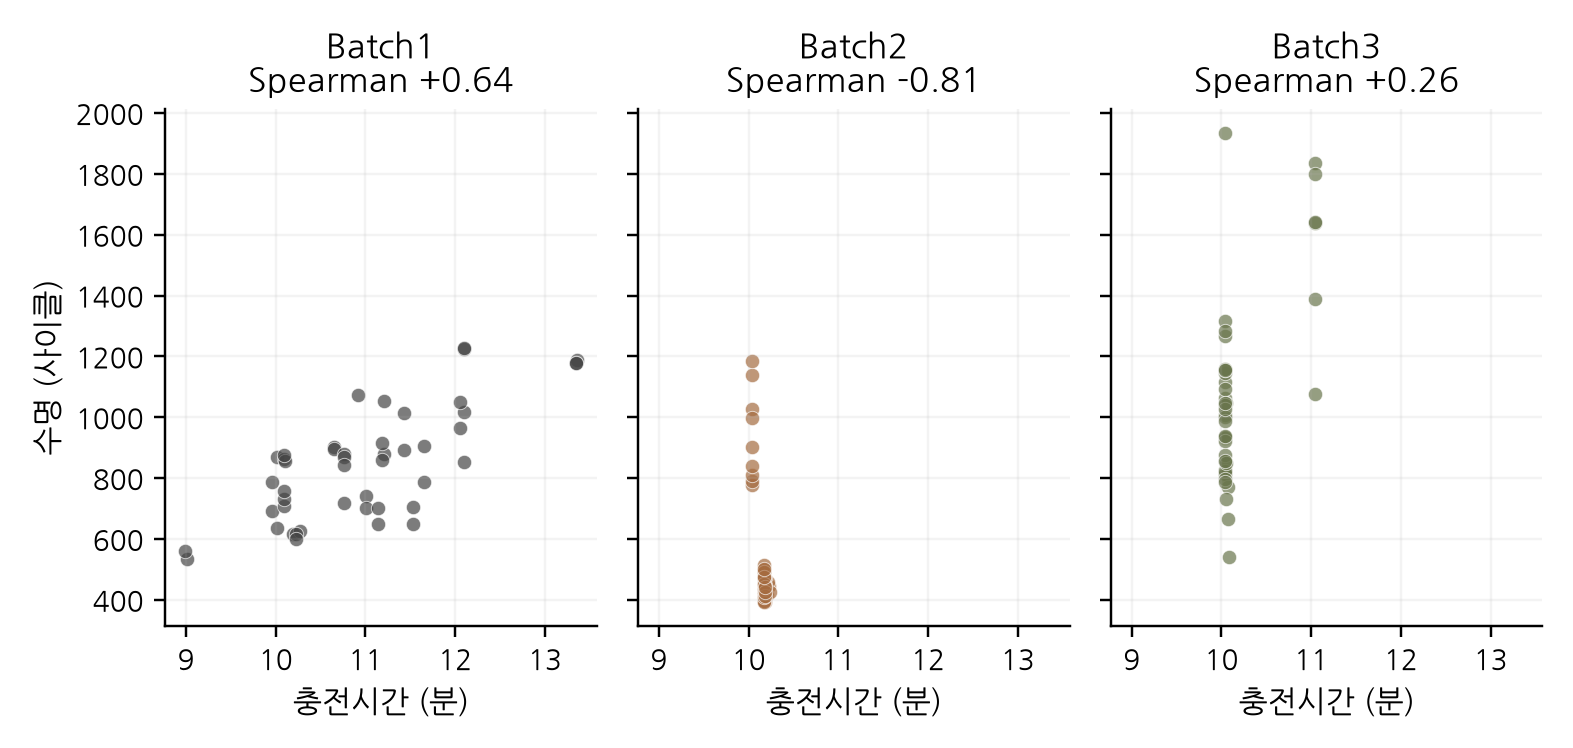

In [5]:
display(Image(filename=str(ROOT / 'day1/readable_figures/13_charge_time_life.png'), width=1000))

### Q5. 상관·중복 → 규제와 제거 비교

IQR과 100-10 용량차의 Pearson r은 Batch1 -0.961, Batch2 -0.408, Batch3 -0.993이다. 독립성을 확보했다고 주장하지 않는다. 기본 A와 IQR 제외 D1·변화량 제외 D2를 동일한 CV에서 비교하고 Ridge·ElasticNet으로 계수 변동을 줄인다. 평균·최고온도의 중복 때문에 평균온도를 기본 후보로 선택했다. IR은 0값 의미 확인 전 보류했다.

## 2. 원본에서 피처 생성

미래 측정값과 관측 종료 시점은 입력에 포함하지 않는다. 공통 전압 격자의 차이만 계산하며 추가 보간하지 않는다. 실제 스파이크 값은 유지한다. 학습·평가에 필요한 모든 피처가 유효한지 확인하고 설계 밖 결측에는 자동 대치하지 않는다.

In [6]:
features = prepare(ROOT / 'data-30', OUTPUT)
display(features.groupby('batch').agg(관측셀=('cell_id','size'), 수명확인=('target_available','sum')))
display(features[['cell_id', 'batch', 'target_available', 'valid_QD_early100']].head())

원본 피처 생성: Batch1


원본 피처 생성: Batch2


원본 피처 생성: Batch3


DAY1 피처와 원본 재생성 피처가 일치합니다.


,관측셀,수명확인
batch,,
Batch1,46,46
Batch2,47,39
Batch3,46,44


,cell_id,batch,target_available,valid_QD_early100
0,Batch1-C00,Batch1,True,99
1,Batch1-C01,Batch1,True,99
2,Batch1-C02,Batch1,True,99
3,Batch1-C03,Batch1,True,99
4,Batch1-C04,Batch1,True,99


## 3. 피처·모델·튜닝 설계

A 5개, B ΔQ 최솟값 대체, C 충전 조건 추가, D1 IQR 제외, D2 용량차 제외를 비교한다. 원수명과 ln수명을 각각 학습하며 로그 예측은 exp로 되돌린 뒤 평가한다. 선형 입력은 학습 폴드에서만 표준화한다.

Mean은 단순 기준선, 한 변수 선형 모델은 ΔQ의 설명력, Ridge·ElasticNet은 소표본과 중복 피처, Forest·Boosting은 비선형 관계를 확인한다. 각 후보 선정 이유와 조정·고정 파라미터의 역할은 아래에 명시한다.

## 모델 후보와 EDA의 연결

| 모델 | 비교 이유 | 학습하는 값 |
|---|---|---|
| Mean | 피처 없이 예측하는 기준보다 개선되는지 확인 | 원수명 평균 또는 ln수명의 평균(역변환하면 기하평균) |
| Univariate | 수명과 강한 관계를 보인 ΔQ log분산 한 개의 설명력 확인 | 계수와 절편 |
| Ridge | 개발 표본 35개와 중복 피처에서 계수 변동을 줄임 | L2 규제가 적용된 계수와 절편 |
| ElasticNet | 중복 피처에서 계수 축소와 일부 계수 0화를 함께 비교 | L1·L2 규제가 적용된 계수와 절편 |
| Random Forest | 비선형 관계와 피처 조합이 선형 모델보다 유리한지 비교 | 부트스트랩으로 학습한 여러 트리의 분기 |
| Gradient Boosting | 앞선 모델의 잔차를 보완하는 비선형 예측 비교 | 순서대로 추가하는 트리의 분기 |

정형 데이터이며 표본이 적어 딥러닝은 사용하지 않는다. 트리 모델은 학습 타깃 범위를 넘는 장수명 외삽이 제한될 수 있으므로 Batch3의 장수명 오차를 별도로 해석한다. 모델 선정은 이러한 예상만으로 정하지 않고 공통 교차검증으로 결정한다.

## Grid Search의 조정 항목

| 모델 | 파라미터 | 비교값 | 역할 |
|---|---|---|---|
| Ridge | `alpha` | 0.01, 0.1, 1, 10, 100 | L2 규제 강도. 커질수록 계수를 줄이지만 너무 크면 과소적합 가능 |
| ElasticNet | `alpha` (원수명) | 0.1, 1, 10, 100 | L1·L2 전체 규제 강도 |
| ElasticNet | `alpha` (ln수명) | 0.0001, 0.001, 0.01, 0.1 | 목표값의 단위와 규모 차이를 고려한 규제 범위 |
| ElasticNet | `l1_ratio` | 0.2, 0.5, 0.8 | L1의 비중. 커지면 일부 계수를 0으로 만드는 성향이 커짐 |
| Random Forest | `max_depth` | 2, 4 | 트리 최대 깊이. 깊을수록 복잡한 관계를 표현 |
| Random Forest | `min_samples_leaf` | 3, 6 | 말단 노드 최소 셀 수. 커질수록 작은 집단에 맞춘 예측을 제한 |
| Gradient Boosting | `learning_rate` | 0.03, 0.1 | 트리 하나가 예측을 수정하는 크기 |
| Gradient Boosting | `n_estimators` | 100, 200 | 순서대로 추가하는 트리 수. 학습률과 함께 비교 |
| Gradient Boosting | `max_depth` | 1, 2 | 각 트리의 복잡도. 1은 단순 분기, 2는 제한적인 상호작용 |

값의 범위는 설계 단계에서 고정한 탐색 범위이며, 범위 밖까지 포함하는 절대적인 최적값을 의미하지 않는다. 한 피처군·목표 변환에서 29개 조합, 5개 피처군 × 2개 목표 변환 × 5-fold = 1,450회 튜닝 학습을 한다. 두 기준 모델 × 두 변환 × 5-fold의 20회가 더해져 CV 학습은 총 1,470회다.

## 고정 설정과 이유

| 적용 | 고정 설정 | 역할과 이유 |
|---|---|---|
| 선형 모델 | `StandardScaler`, `fit_intercept=True` | 피처 단위가 규제 크기를 좌우하지 않도록 학습 폴드의 평균·표준편차로 표준화. 절편 학습 |
| ElasticNet | `max_iter=10000`, `tol=1e-4`, `selection='cyclic'` | 반복 상한·수렴 허용오차·계수 갱신 순서. 경고와 실제 반복 수 기록 |
| Random Forest | `n_estimators=300`, `bootstrap=True` | 중복 허용한 셀 표본으로 여러 트리를 만들고 평균화 |
| Random Forest | `max_features=1.0`, `criterion='squared_error'` | 모든 입력 피처를 분기 후보로 보고 제곱오차 감소로 분기 |
| Gradient Boosting | `min_samples_leaf=3`, `loss='squared_error'` | 아주 작은 말단 노드를 제한하고 잔차의 제곱오차를 줄임 |
| Gradient Boosting | `subsample=1.0`, `n_iter_no_change=None` | 각 단계의 학습 셀 전체 사용. 추가 내부 검증셋 대신 공통 CV로 트리 수 비교 |
| 분리·트리 모델 | `random_state=42` | 같은 실험 재현. 좋은 seed를 탐색하지 않음 |
| 교차검증 | `GroupKFold(n_splits=5, shuffle=False)` | 원문 충전 정책 문자열로 분리. 같은 정책이 한 폴드의 학습·검증에 겹치지 않음 |

모델의 학습 목적함수는 제곱오차 기반이며, 설정을 선택하는 검증 지표는 MAPE다. 둘을 구분한다. 모든 API 기본값은 실행 버전과 함께 `day2/results/estimator_parameters.json`에 저장한다.

In [7]:
display(pd.DataFrame([{'피처군': g, '입력수': len(fs), '피처': ', '.join(fs)}
                      for g, fs in design['feature_groups'].items()]))
print('개발:', len(holdout['development_cell_ids']), '셀')
print('별도 검증:', len(holdout['holdout_cell_ids']), '셀')

,피처군,입력수,피처
0,A,5,"deltaq_log10var, qd_median, qd_iqr, qd_change1..."
1,B,5,"deltaq_min, qd_median, qd_iqr, qd_change100_10..."
2,C,9,"deltaq_log10var, qd_median, qd_iqr, qd_change1..."
3,D1,4,"deltaq_log10var, qd_median, qd_change100_10, t..."
4,D2,4,"deltaq_log10var, qd_median, qd_iqr, temp_mean"


개발: 35 셀
별도 검증: 11 셀


## 4. 정책별 Grid Search와 모델 선정

개발 35셀의 정책별 5-fold를 모든 후보에 동일하게 적용한다. 정답을 원래 단위로 예측한 5개 폴드 MAPE의 산술평균이 주 지표다. 각 가중치는 1/5이며 반올림 전 최솟값으로 선정한다. Batch2·3은 후보 점수 계산에 사용하지 않는다. 290개 튜닝 조합과 기준 후보 4개로 총 1,470회 학습한다.

In [8]:
winner = tune(features, OUTPUT, jobs=4)
cv = pd.read_csv(OUTPUT / 'cv_results.csv')
champions = cv.sort_values('mean_cv_mape_pct').drop_duplicates('model')
display(champions[['model','feature_group','target_transform','mean_cv_mape_pct','std_cv_mape_pct','params_json']])
display(pd.DataFrame(winner['fold_results']))
display(Markdown(f"**선정:** {winner['model']} / {winner['feature_group']} / {winner['target_transform']} / {winner['params']}\n\nCV MAPE {winner['mean_cv_mape_pct']:.3f}% · pooled OOF {winner['pooled_oof_mape_pct']:.3f}%"))

Grid Search 시작: 294개 후보 × 5-fold = 1,470회 학습


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.9s


[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    4.6s


CV 선정 완료: ElasticNet / D1 / ln / MAPE 6.230%


[Parallel(n_jobs=4)]: Done 294 out of 294 | elapsed:    7.7s finished


,model,feature_group,target_transform,mean_cv_mape_pct,std_cv_mape_pct,params_json
0,ElasticNet,D1,ln,6.229801,1.890896,"{""alpha"": 0.01, ""l1_ratio"": 0.5}"
6,Ridge,D1,identity,6.492788,1.723825,"{""alpha"": 0.1}"
32,Univariate,univariate,ln,7.134497,2.409528,{}
91,GradientBoosting,D2,ln,9.072370,4.413558,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti..."
96,RandomForest,D2,ln,9.430337,5.078487,"{""max_depth"": 2, ""min_samples_leaf"": 3}"
292,Mean,baseline,identity,19.005689,9.189480,{}


,mape_pct,mae_cycles,rmse_cycles,fold,n_train,n_validation,n_iter
0,3.657008,33.587022,60.891421,1,27,8,3
1,6.798072,49.801407,66.454002,2,27,8,8
2,8.380846,83.736003,106.673502,3,28,7,13
3,4.989915,40.388780,44.464092,4,29,6,7
4,7.323166,65.746353,74.670731,5,29,6,8


**선정:** ElasticNet / D1 / ln / {'alpha': 0.01, 'l1_ratio': 0.5}

CV MAPE 6.230% · pooled OOF 6.177%

## 5. 고정한 모델의 최종 평가

선정 결과를 저장한 뒤 개발 35셀로 최종 fit한다. Train은 같은 학습 셀, CV는 학습에서 보류한 폴드, Valid는 별도 Batch1 11셀이다. Batch2 39셀과 Batch3 44셀에도 같은 모델을 적용한다. 평가 점수로 설정을 바꾸지 않는다.

In [9]:
scores = evaluate(features, OUTPUT)
make_figures(OUTPUT)
cv_row = pd.DataFrame([{'split': 'CV (5-fold mean)', 'n': 35,
    'mape_pct': winner['mean_cv_mape_pct'], 'mae_cycles': winner['mean_cv_mae_cycles'],
    'rmse_cycles': winner['mean_cv_rmse_cycles']}])
display(pd.concat([scores.iloc[:1], cv_row, scores.iloc[1:]], ignore_index=True))
display(pd.read_csv(OUTPUT / 'feature_group_comparison.csv'))

            split  n  mape_pct  mae_cycles  rmse_cycles
            Train 35  5.857822   50.786565    66.478194
            Valid 11 14.965119  155.196403   228.069902
      Test_Batch2 39 40.812669  208.366205   222.437201
Additional_Batch3 44 12.651746  160.199610   256.477650


결과 그래프 7개 저장: /Users/u090/Desktop/mini project data/day2/results/figures


,split,n,mape_pct,mae_cycles,rmse_cycles
0,Train,35,5.857822,50.786565,66.478194
1,CV (5-fold mean),35,6.229801,54.651913,70.630750
2,Valid,11,14.965119,155.196403,228.069902
3,Test_Batch2,39,40.812669,208.366205,222.437201
4,Additional_Batch3,44,12.651746,160.199610,256.477650


,feature_group,model,target_transform,candidate_id,params_json,mean_cv_mape_pct,std_cv_mape_pct,mean_cv_mae_cycles,mean_cv_rmse_cycles,pooled_oof_mape_pct,warning_count
0,A,ElasticNet,ln,candidate-162,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",6.485123,1.691906,56.071967,70.000857,6.462655,0
1,B,ElasticNet,ln,candidate-192,"{""alpha"": 0.1, ""l1_ratio"": 0.2}",7.373557,1.740440,63.236422,81.681035,7.463601,0
2,C,ElasticNet,ln,candidate-220,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",6.699170,1.113702,56.596212,70.415021,6.668009,0
3,D1,ElasticNet,ln,candidate-248,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",6.229801,1.890896,54.651913,70.630750,6.176716,0
4,D2,ElasticNet,ln,candidate-278,"{""alpha"": 0.01, ""l1_ratio"": 0.8}",6.485123,1.691906,56.071967,70.000857,6.462655,0


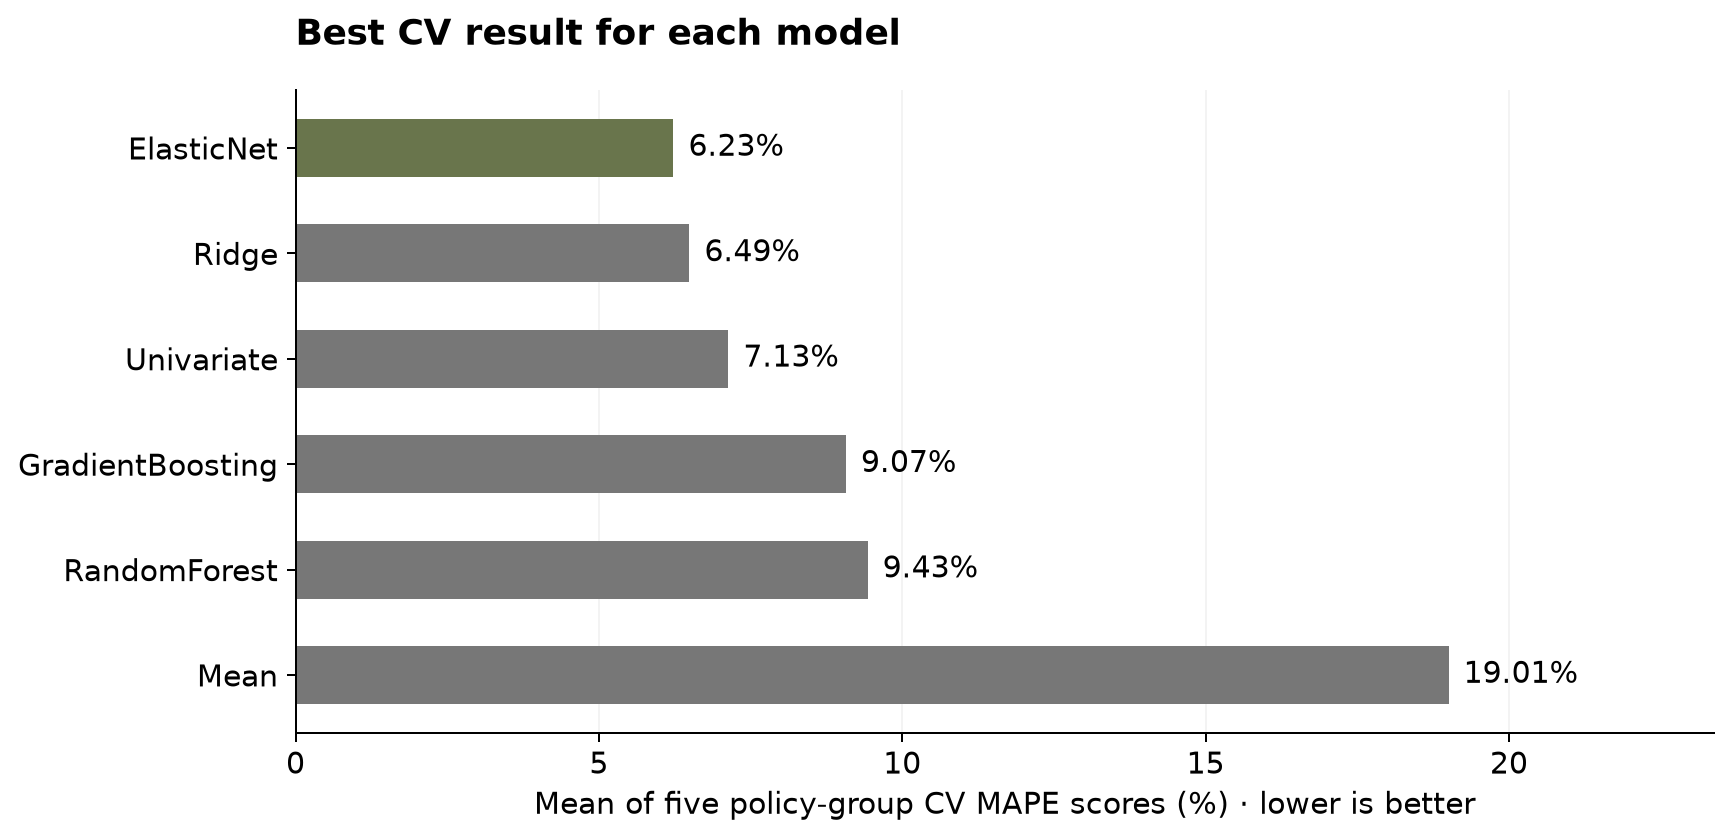

In [10]:
display(Image(filename=str(OUTPUT / 'figures/01_model_comparison.png'), width=1000))

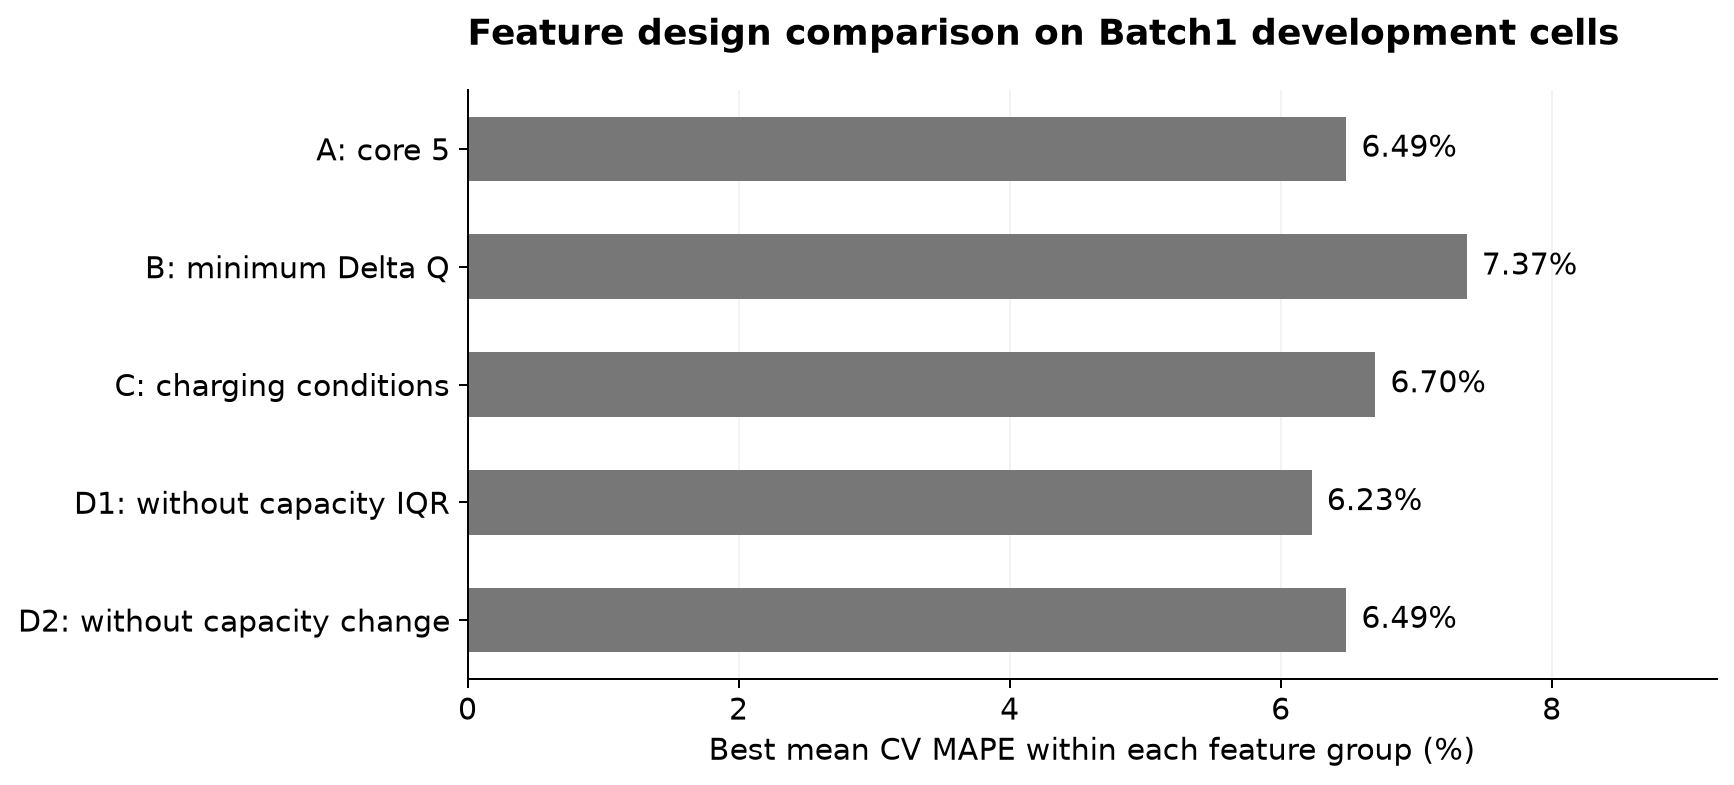

In [11]:
display(Image(filename=str(OUTPUT / 'figures/07_feature_group_comparison.png'), width=1000))

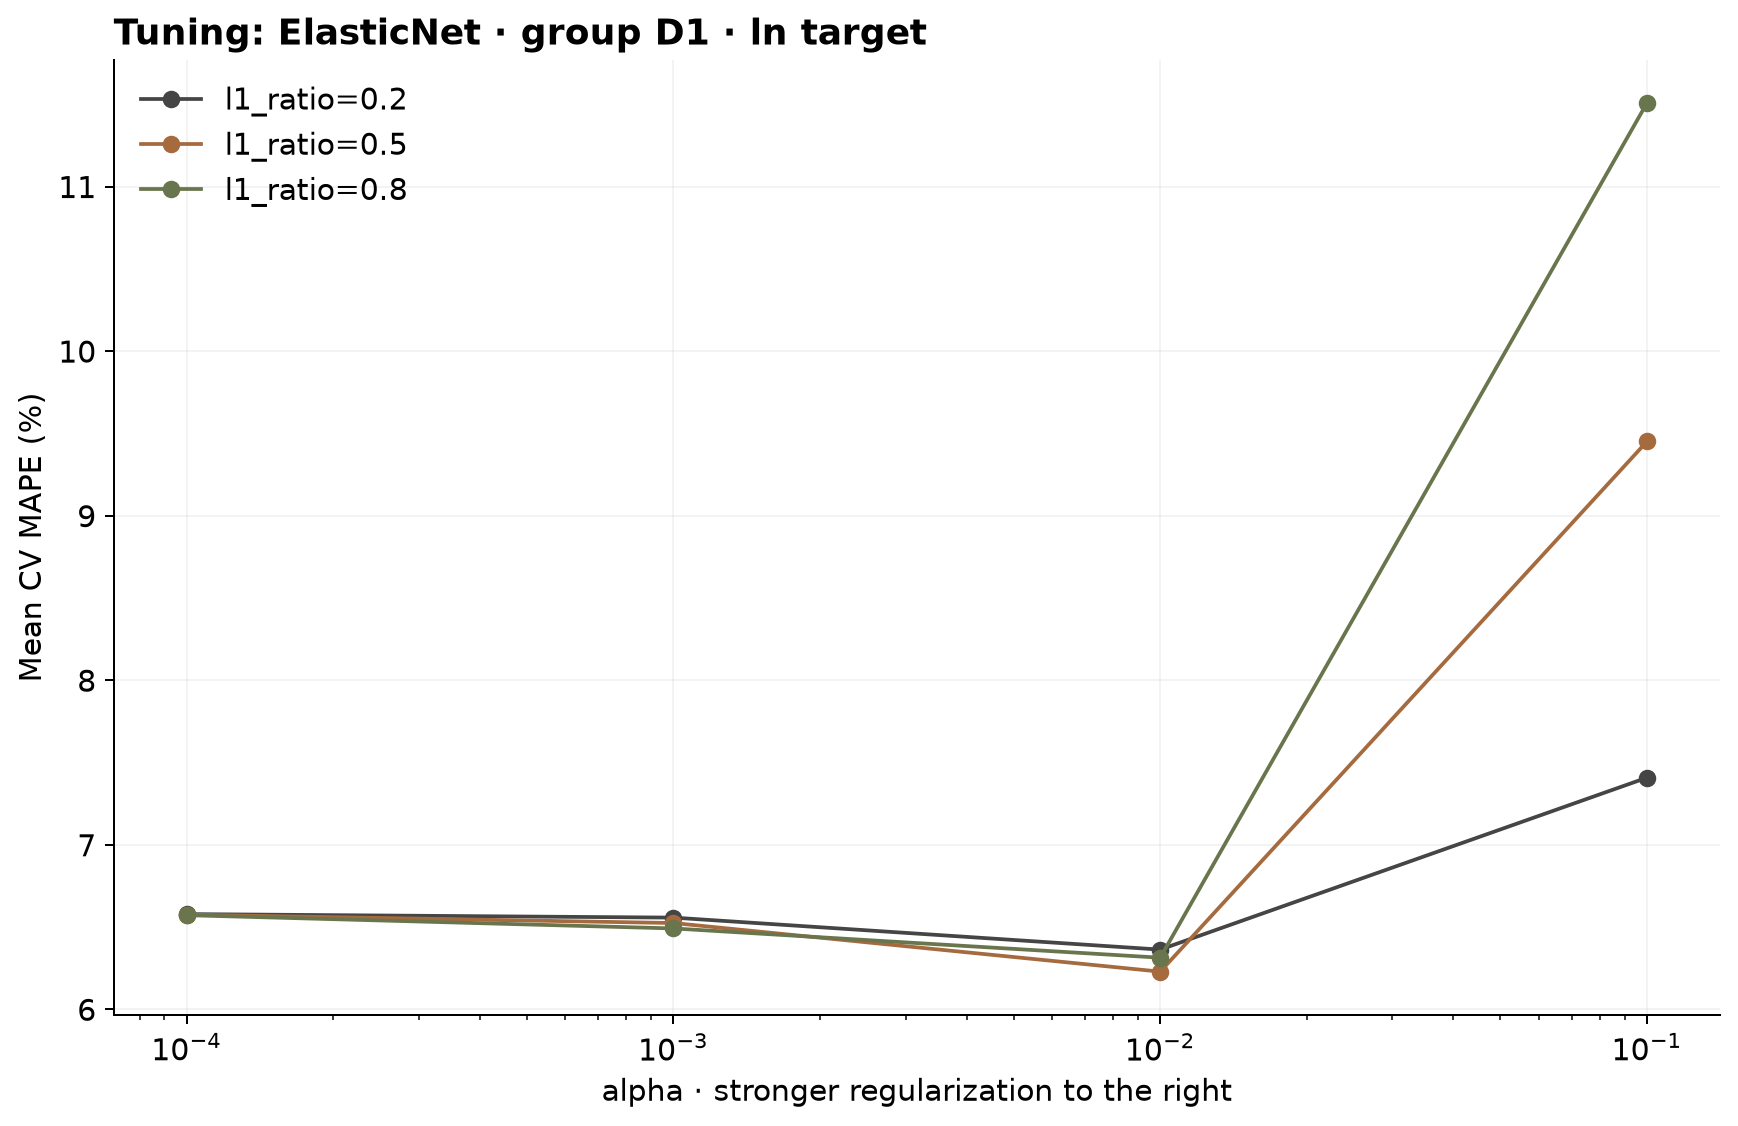

In [12]:
display(Image(filename=str(OUTPUT / 'figures/05_selected_model_tuning.png'), width=1000))

**해석:** ElasticNet·D1·ln수명이 비교 범위에서 가장 낮은 CV 평균 MAPE를 얻었다. IQR을 제외한 조합이 유리했으며 규제와 중복 피처 검증이라는 설계가 구현에 연결됐다. alpha=0.01, l1_ratio=0.5가 선정됐다. 온도 계수는 0이지만 입력군을 평가 후 다시 바꾸지 않는다. CV 최솟값은 탐색한 후보 중 결과이며 전역 최적이나 외부 성능을 보장하지 않는다.

### 원수명·로그 기준선과 같은 설정의 피처 비교

원수명 평균 기준선과 로그 역변환 기준선은 각각 계산한다. 피처군별 최저점 비교는 모델 설정도 다를 수 있으므로, 같은 ElasticNet·ln수명·alpha=0.01·l1_ratio=0.5의 결과도 대조한다.

| model | target_transform | mean_cv_mape_pct | std_cv_mape_pct |
| --- | --- | --- | --- |
| Univariate | ln | 7.134 | 2.410 |
| Univariate | identity | 7.201 | 2.812 |
| Mean | identity | 19.006 | 9.189 |
| Mean | ln | 19.207 | 8.514 |

| feature_group | mean_cv_mape_pct | std_cv_mape_pct |
| --- | --- | --- |
| A | 6.755 | 1.238 |
| B | 8.311 | 2.410 |
| C | 7.280 | 0.776 |
| D1 | 6.230 | 1.891 |
| D2 | 6.686 | 1.310 |

D1과 A의 차이는 약 0.526pp다. 동일한 설정에서 IQR 제외 조합이 낮은 오차를 보였으며, 외부 성능 개선을 보장하지 않는다.

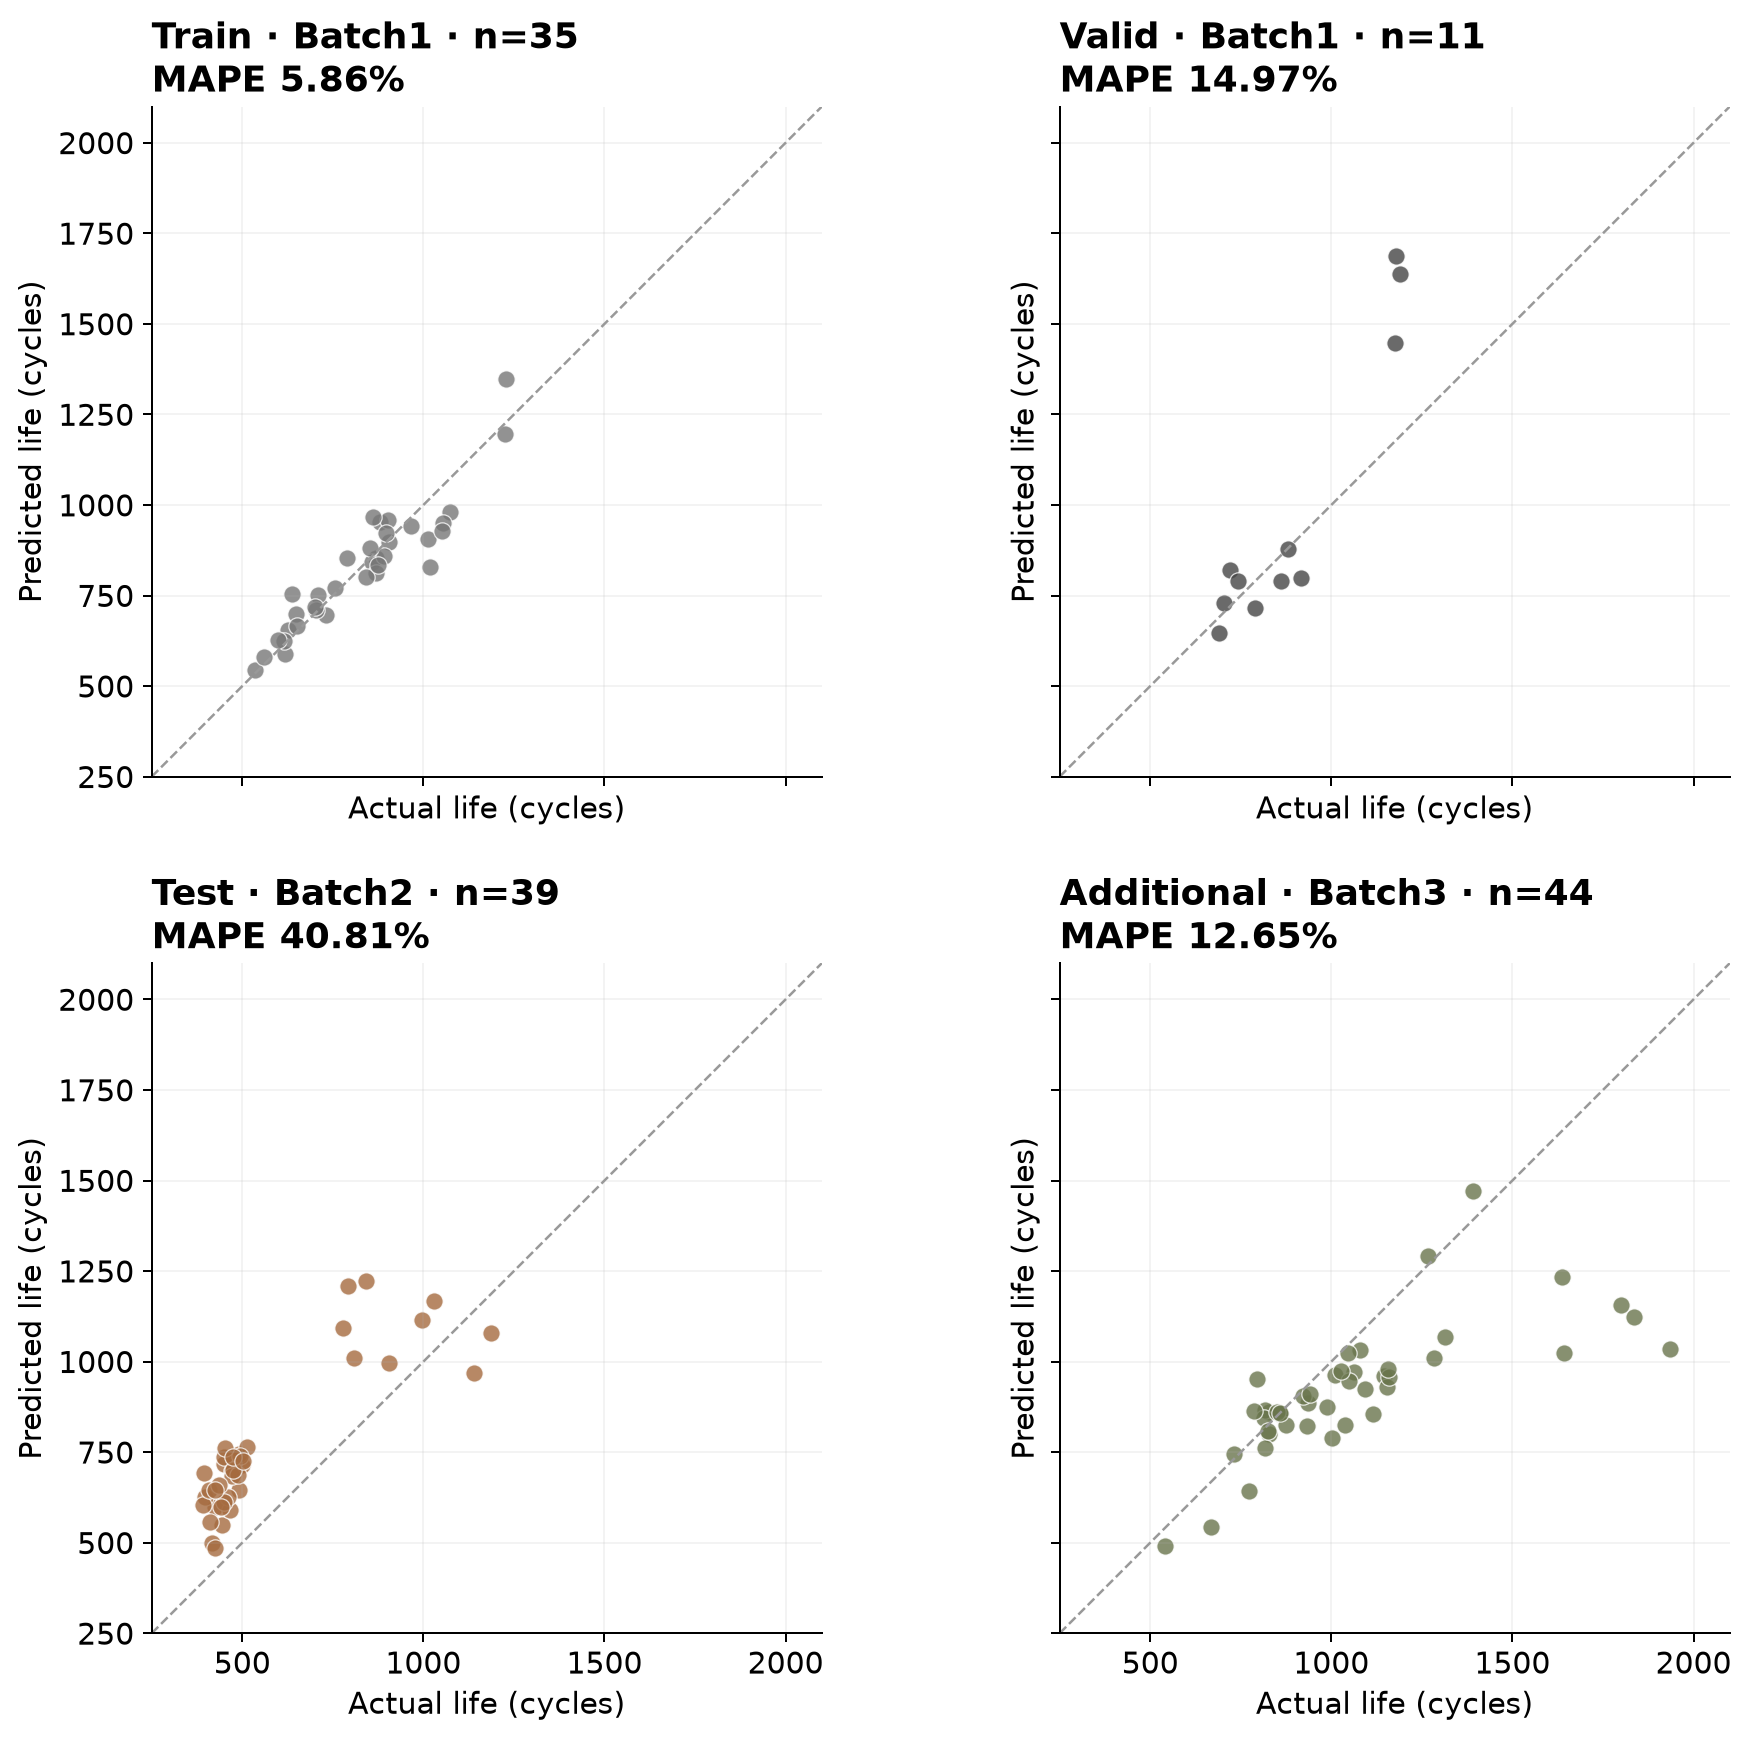

In [13]:
display(Image(filename=str(OUTPUT / 'figures/02_actual_vs_predicted.png'), width=1000))

## 6. 오류 분석과 일반화 한계

CV 6.23%, Valid 14.97%, Batch2 40.81%, Batch3 12.65%로 평가 조건에 따라 차이가 크다. 특히 Batch2의 단수명 셀을 과대 예측했다. 개발 학습에서 짧은 수명과 해당 입력 범위를 충분히 관측하지 못한 점을 함께 확인한다. 이 차이를 특정 피처 하나의 인과효과로 단정하지 않는다.

In [14]:
display(pd.read_csv(OUTPUT / 'subgroup_metrics.csv'))
display(pd.read_csv(OUTPUT / 'feature_range_shift.csv'))
display(pd.read_csv(OUTPUT / 'long_life_cells.csv'))
display(pd.read_csv(OUTPUT / 'largest_errors.csv').head(5))

,split,life_group,n,mape_pct,mae_cycles,rmse_cycles,bias_cycles
0,Additional_Batch3,500-1000,21,6.788314,54.516589,70.690232,-19.415481
1,Additional_Batch3,>1000,23,18.005314,256.692802,348.251237,-247.477788
2,Test_Batch2,500-1000,8,34.814387,249.796859,272.766808,249.796859
3,Test_Batch2,<500,28,45.562712,204.000256,213.362673,204.000256
4,Test_Batch2,>1000,3,12.474354,138.633327,141.160108,-46.825892
5,Train,500-1000,28,4.758923,36.052977,45.271704,14.949304
6,Train,>1000,7,10.253419,109.720915,117.892505,-75.490877
7,Valid,500-1000,8,7.602970,59.970751,70.080879,-15.734405
8,Valid,>1000,3,34.597516,409.131476,421.459387,409.131476


,split,feature,n,development_min,development_max,development_median,evaluation_median,below_development_min,above_development_max
0,Valid,deltaq_log10var,11,-4.647309,-3.349904,-3.853269,-3.848182,3,0
1,Valid,qd_median,11,1.060556,1.097334,1.083061,1.080198,0,0
2,Valid,qd_change100_10,11,-0.014476,0.002100,-0.000972,-0.000137,0,0
3,Valid,temp_mean,11,29.942199,33.894970,32.959699,32.664552,0,0
4,Test_Batch2,deltaq_log10var,39,-4.647309,-3.349904,-3.853269,-3.486830,0,11
5,Test_Batch2,qd_median,39,1.060556,1.097334,1.083061,1.097976,0,21
6,Test_Batch2,qd_change100_10,39,-0.014476,0.002100,-0.000972,0.000254,1,14
7,Test_Batch2,temp_mean,39,29.942199,33.894970,32.959699,33.015504,1,5
8,Additional_Batch3,deltaq_log10var,44,-4.647309,-3.349904,-3.853269,-4.174769,3,0
9,Additional_Batch3,qd_median,44,1.060556,1.097334,1.083061,1.067709,9,0


,cell_id,batch,policy,cycle_life,split,prediction,error_cycles,absolute_error_cycles,ape_pct,life_group
0,Batch3-C07,Batch3,4.8C(80%)-4.8C-newstructure,1836.0,Additional_Batch3,1124.396610,-711.603390,711.603390,38.758355,>1000
1,Batch3-C38,Batch3,5C(67%)-4C-newstructure,1935.0,Additional_Batch3,1034.375747,-900.624253,900.624253,46.543889,>1000
2,Batch3-C45,Batch3,4.8C(80%)-4.8C-newstructure,1801.0,Additional_Batch3,1156.945694,-644.054306,644.054306,35.760928,>1000


,cell_id,batch,policy,cycle_life,split,prediction,error_cycles,absolute_error_cycles,ape_pct,life_group
0,Batch2-C06,Batch2,3.6C(9%)-5C,393.0,Test_Batch2,693.059976,300.059976,300.059976,76.351139,<500
1,Batch2-C29,Batch2,5.2C(58%)-4C,452.0,Test_Batch2,762.807597,310.807597,310.807597,68.762743,<500
2,Batch2-C18,Batch2,5.2C(50%)-4.25C,449.0,Test_Batch2,735.736558,286.736558,286.736558,63.861149,<500
3,Batch2-C11,Batch2,5.2C(50%)-4.25C,449.0,Test_Batch2,717.670710,268.670710,268.670710,59.837575,<500
4,Batch2-C15,Batch2,3.6C(9%)-5C,396.0,Test_Batch2,627.645868,231.645868,231.645868,58.496431,<500


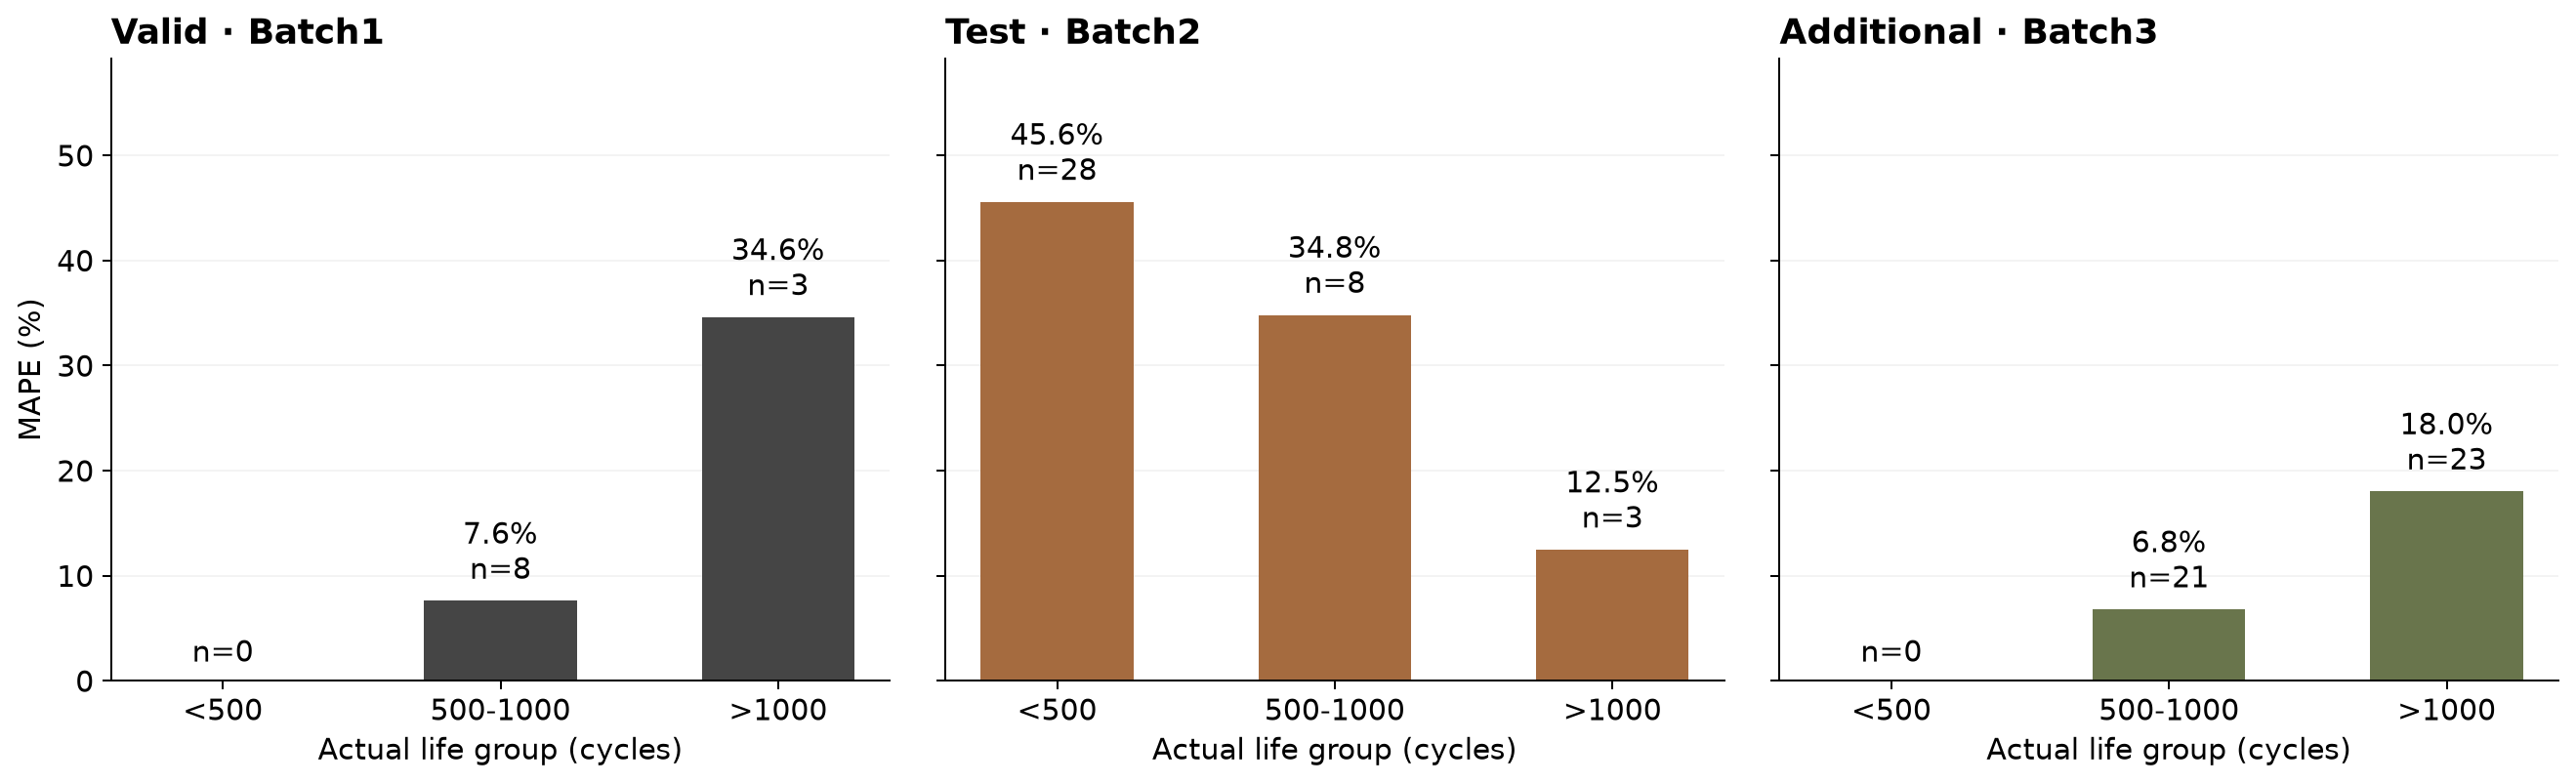

In [15]:
display(Image(filename=str(OUTPUT / 'figures/04_lifetime_group_errors.png'), width=1000))

**해석:** Batch2 <500사이클 28셀의 MAPE 45.56%, 평균 과대 예측 약 204사이클이다. Batch3 >1000사이클 23셀은 MAPE 18.01%, 평균 과소 예측 약 247사이클이다. C07·C38·C45는 35.76-46.54%의 오차를 보였다. 장수명 이상치 후보는 실제 평가에 남겼다.

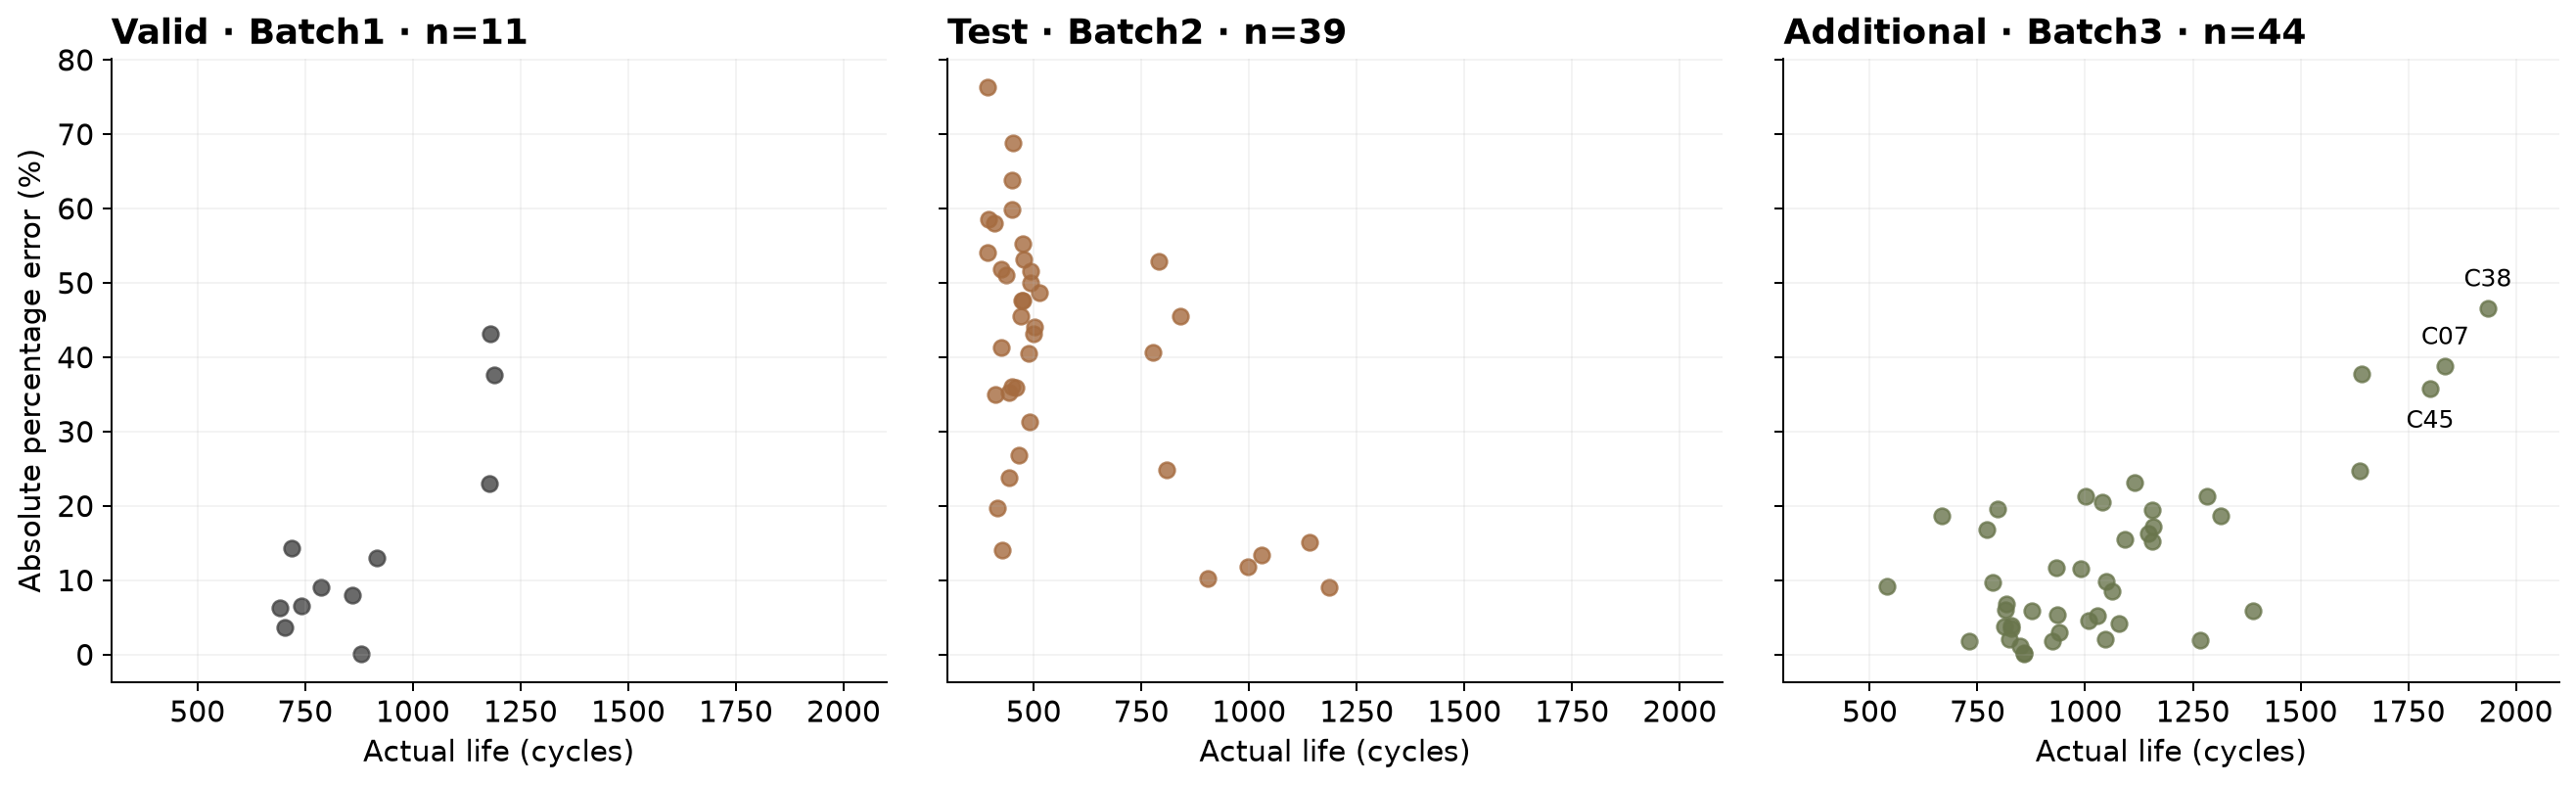

In [16]:
display(Image(filename=str(OUTPUT / 'figures/03_error_by_lifetime.png'), width=1000))

### 피처 기여와 해석

Valid 입력을 30회 섞어 MAPE 변화를 확인한다. 모델 재선정에는 사용하지 않는다. 중복 피처의 중요도는 분산될 수 있으며 작은 음수는 이 표본에서 기여가 명확하지 않다는 의미다. 선형 계수는 표준화 입력과 ln수명 사이의 값으로, 사이클 증가량과 동일하게 읽지 않는다.

,feature,increase_mape_pp,repeat_sd_pp
0,deltaq_log10var,18.567075,5.341297
1,qd_median,0.985284,1.043335
2,qd_change100_10,-0.101942,0.040433
3,temp_mean,0.000000,0.000000


,feature,coefficient_standardized_x
0,deltaq_log10var,-0.188821
1,qd_median,0.043150
2,qd_change100_10,0.001965
3,temp_mean,-0.000000


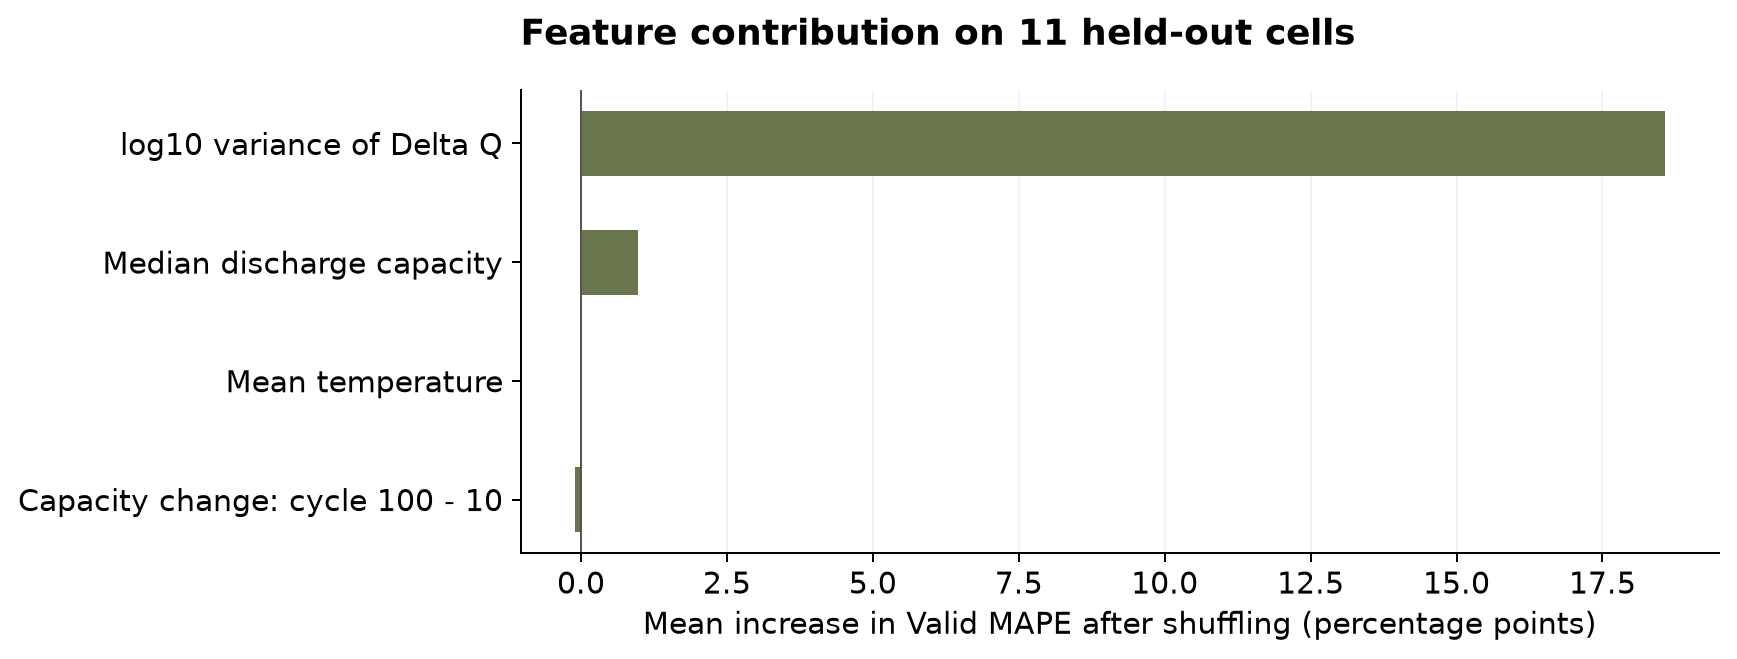

In [17]:
display(pd.read_csv(OUTPUT / 'permutation_importance_valid.csv'))
if (OUTPUT / 'linear_coefficients.csv').exists():
    display(pd.read_csv(OUTPUT / 'linear_coefficients.csv'))
display(Image(filename=str(OUTPUT / 'figures/06_feature_contribution.png'), width=1000))

## 7. 논문 성능 비교

초기 100사이클을 이용한 논문의 참고 테스트 오차는 9.1%다. 본 Batch2는 +31.71pp, Batch3는 +3.55pp로 더 크다. CV만으로 논문보다 우수하다고 주장할 수 없다.

논문은 정제된 124셀(41/43/40), 본 실험은 원본 139셀 중 수명 확인 129셀과 정책별 분리를 사용한다. 저자의 연속 실험 연결과 제외까지 동일한 재현이 아니다. DAY1에서 평가 대상 수명을 이미 EDA로 확인한 점도 한계다. [원논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

In [18]:
display(pd.Series(json.loads((OUTPUT / 'performance_gaps.json').read_text())))

valid_minus_train_pp                                                   9.107297
valid_minus_cv_pp                                                      8.735318
test_batch2_minus_valid_pp                                             25.84755
test_batch2_minus_paper_pp                                            31.712669
batch3_minus_paper_pp                                                  3.551746
paper_reference_mape_pct                                                    9.1
comparable_protocol                                                       False
interpretation                positive means the first-named error is larger...
dtype: object

## 8. 실험을 통해 배운 점과 다음에 확인할 내용

DAY1에서 ΔQ log분산과 수명의 관계가 강하게 나타나 이 신호를 중심으로 회귀 모델을 설계했다. 용량 피처의 중복을 줄이는 비교와 규제 모델, 비선형 모델을 같은 정책별 교차검증에 적용했다. 그 결과 IQR을 제외한 D1군의 ElasticNet이 선정됐다. 원본 피처 재생성, 학습 폴드에서만 수행하는 표준화, 로그 예측의 역변환, 고정된 셀 분리를 코드로 연결했고 전체 실행에서도 같은 결과가 재현됐다. 이 과정을 통해 EDA에서 정한 선택을 실제 실험으로 확인할 수 있었다.

CV MAPE는 6.23%였지만 Batch2에서는 40.81%로 커졌다. 오차를 셀별로 확인하니 39개 중 37개의 수명을 길게 예측했고, 500사이클 미만 28개는 평균 약 204사이클 과대 예측했다. 개발 데이터에는 500사이클 미만 셀이 하나도 없었다. **짧은 수명을 학습할 관측이 부족한 상태에서 그 영역까지 예측하게 한 점이 이번 설계의 한계였다.** 앞으로는 모델을 고르기 전에 학습 데이터가 예측 대상의 수명 범위와 입력 조건을 충분히 포함하는지 먼저 확인해야겠다고 생각했다.

입력 범위도 함께 살펴봤다. Batch2에서는 초기 용량 중앙값 21/39셀과 ΔQ log분산 11/39셀이 개발 데이터의 최댓값을 넘었다. 선정 모델의 용량 중앙값 계수는 양수여서 용량이 높으면 수명을 길게 예측하는 방향으로 작용한다. Batch2는 초기 용량이 높으면서 실제 수명은 짧은 셀이 많았기 때문에, 초기 용량의 절대값을 다른 Batch에도 같은 의미로 적용해도 되는지 의문이 생겼다. 분포 차이와 계수의 방향은 오차를 설명하는 근거지만, 이것만으로 용량 피처가 성능 저하의 주원인이라고 확정할 수는 없다.

피처를 추가하거나 제거한 결과도 배울 점이 있었다. 같은 ElasticNet·ln수명·alpha=0.01·l1_ratio=0.5에서 기본 A군은 6.755%, IQR을 제외한 D1군은 6.230%였다. 중복 피처를 점검한 선택이 이 CV 비교에서는 도움이 됐다. 반면 충전 조건을 추가한 C군은 같은 설정에서 7.280%였다. 최종 온도 계수는 0이 됐다. **EDA에서 관련이 있어 보이는 변수도 실제 예측에 얼마나 기여하는지는 별도로 확인해야 한다는 점을 배웠다.** 이 결과는 개발 표본 35개에서 얻은 비교이므로 다른 데이터에서도 같은 효과가 나타난다고 일반화하지 않는다.

이번 정책별 CV는 Batch1 안에서 새로운 충전 정책을 예측하는 상황을 평가했다. Batch2처럼 수명과 입력 분포가 다른 실험 집단으로 옮겨 가는 상황까지 충분히 검증하지 못했다. 따라서 CV가 낮다는 사실과 함께, 그 점수가 어떤 데이터와 분리 방식에서 나온 것인지 설명해야 한다. 논문의 9.1%와 비교할 때도 셀 구성·전처리·분리 조건을 확인해야 한다고 느꼈다. 이번에는 논문 성능에 도달하지 못했지만, 오차가 커지는 영역과 현재 설계가 다루지 못한 조건을 구체적으로 확인했다.

다음 실험에서는 아래 가설을 하나씩 검증해 보고 싶다. 아직 수행하지 않은 계획이며 성능 향상을 보장하는 결과는 아니다.

| 다음에 확인할 문제 | 실험해 볼 방법 | 확인할 결과 |
| --- | --- | --- |
| 학습에 단수명 영역이 부족함 | 단수명 셀과 다양한 충전 조건을 포함한 추가 학습 데이터를 확보하고, 평가 데이터는 별도로 고정 | 단수명 구간의 과대 예측·MAPE·MAE가 함께 줄어드는지 |
| 초기 용량의 절대값이 Batch 차이를 반영할 수 있음 | 기존 절대 용량 피처와 `Qd / Qd10` 같은 상대 용량 요약을 같은 개발 분할에서 비교 | Batch 차이에 덜 민감해지면서 수명 신호를 유지하는지. 상대화가 유용한 정보까지 없애는지도 확인 |
| 정책별 CV가 다른 Batch의 성능을 충분히 보여주지 못함 | 추가 데이터가 확보되면 Batch 단위로 학습·검증을 나누는 평가도 설계 | 같은 Batch 내부 점수와 다른 Batch에서의 점수 차이가 얼마나 큰지 |

이번 Batch2·3 평가 결과는 그대로 보존한다. 후속 실험에서 이미 확인한 평가 데이터로 설정을 다시 고르면 그 점수는 탐색 결과로 구분하고, 최종 성능은 별도의 미사용 데이터로 확인해야 한다. 다음 실험의 방향과 범위는 이 가설들을 비교한 뒤 정한다.

## 9. ESS 활용과 한계

초기 수명 위험의 선별과 추가 점검 우선순위를 정하는 보조 신호로 검토할 수 있다. 다만 실험실의 LFP/graphite 셀과 고속 충전 조건은 실제 ESS의 부하·온도·달력 열화·팩 운용을 대표하지 않는다. Batch2 과대 예측은 단수명 위험을 낮게 평가할 수 있어 직접적인 교체·안전 제어에 적용할 근거가 부족하다.

별도의 ESS 운용 데이터, 수명 정의 일치, 입력 범위 점검과 외부 검증이 필요하다. 이번 평가값으로 재튜닝한 결과를 기존 테스트와 섞지 않는다. [실험 조건](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

## 10. 재현 기록과 산출물

설정·분할·예측·모델·환경을 저장했다. 모델을 재로딩한 예측 일치와 선정 파일이 평가 중 바뀌지 않았음을 확인한다. 데이터 누출 관련 계약 검증은 `python -m unittest discover -s tests -v`로 실행한다.

In [19]:
manifest = json.loads((OUTPUT / 'run_manifest.json').read_text())
display(pd.Series({k: manifest[k] for k in ['python', 'model_reload_prediction_check',
    'selection_unchanged_during_evaluation', 'convergence_warning_count_cv', 'negative_prediction_count']}))
print('결과 파일:', ', '.join(p.name for p in sorted(OUTPUT.glob('*.csv'))))

python                                   3.11.15
model_reload_prediction_check             passed
selection_unchanged_during_evaluation       True
convergence_warning_count_cv                   0
negative_prediction_count                      0
dtype: object

결과 파일: all_oof_predictions.csv, cv_results.csv, feature_group_comparison.csv, feature_range_shift.csv, features.csv, largest_errors.csv, linear_coefficients.csv, long_life_cells.csv, matched_feature_comparison.csv, metrics.csv, permutation_importance_valid.csv, predictions.csv, selected_oof_predictions.csv, subgroup_metrics.csv


## 참고문헌과 역할

- Severson et al. (2019), [Nature Energy 논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)
- [저자 공개 데이터 처리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation)
- [Kaggle 데이터](https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle/data)
- [scikit-learn 모델·검증 문서](docs/modeling.md#참고)

U090 이나현: EDA 해석, 피처·모델 전략 결정, 결과 검토 및 제출.